<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nelson/customer_segmentation_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Clustering: [UCI - Online Retail]
**Nama - ID:**
- Leonardo Sanjaya  | M320D5Y0992
- Nelson Ahli       | M320D5Y1490
- Steven Gunawan    | M320D5Y1870

# **Import Library**


In [1]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import zipfile

from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import plotly.graph_objs as go
import plotly.io as pio

In [2]:
try:
    import google.colab # type: ignore
    pio.renderers.default = "colab"

except Exception:
    pass

# **Data Loading**


In [3]:
# Mengambil dataset dari Kaggle
if not os.path.exists('../assets/Online Retail.csv'):
  os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
  shutil.copy('../kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
  
  !kaggle datasets download -d viridianachow/online-retail-uci-dataset
  
  with zipfile.ZipFile('online-retail-uci-dataset.zip', 'r') as zip_ref:
      zip_ref.extractall('../assets')

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
online-retail-uci-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
df = pd.read_csv('../assets/Online Retail.csv')

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


## **Exploratory Data Analysis (EDA)**

In [5]:
sns.set_style("whitegrid")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


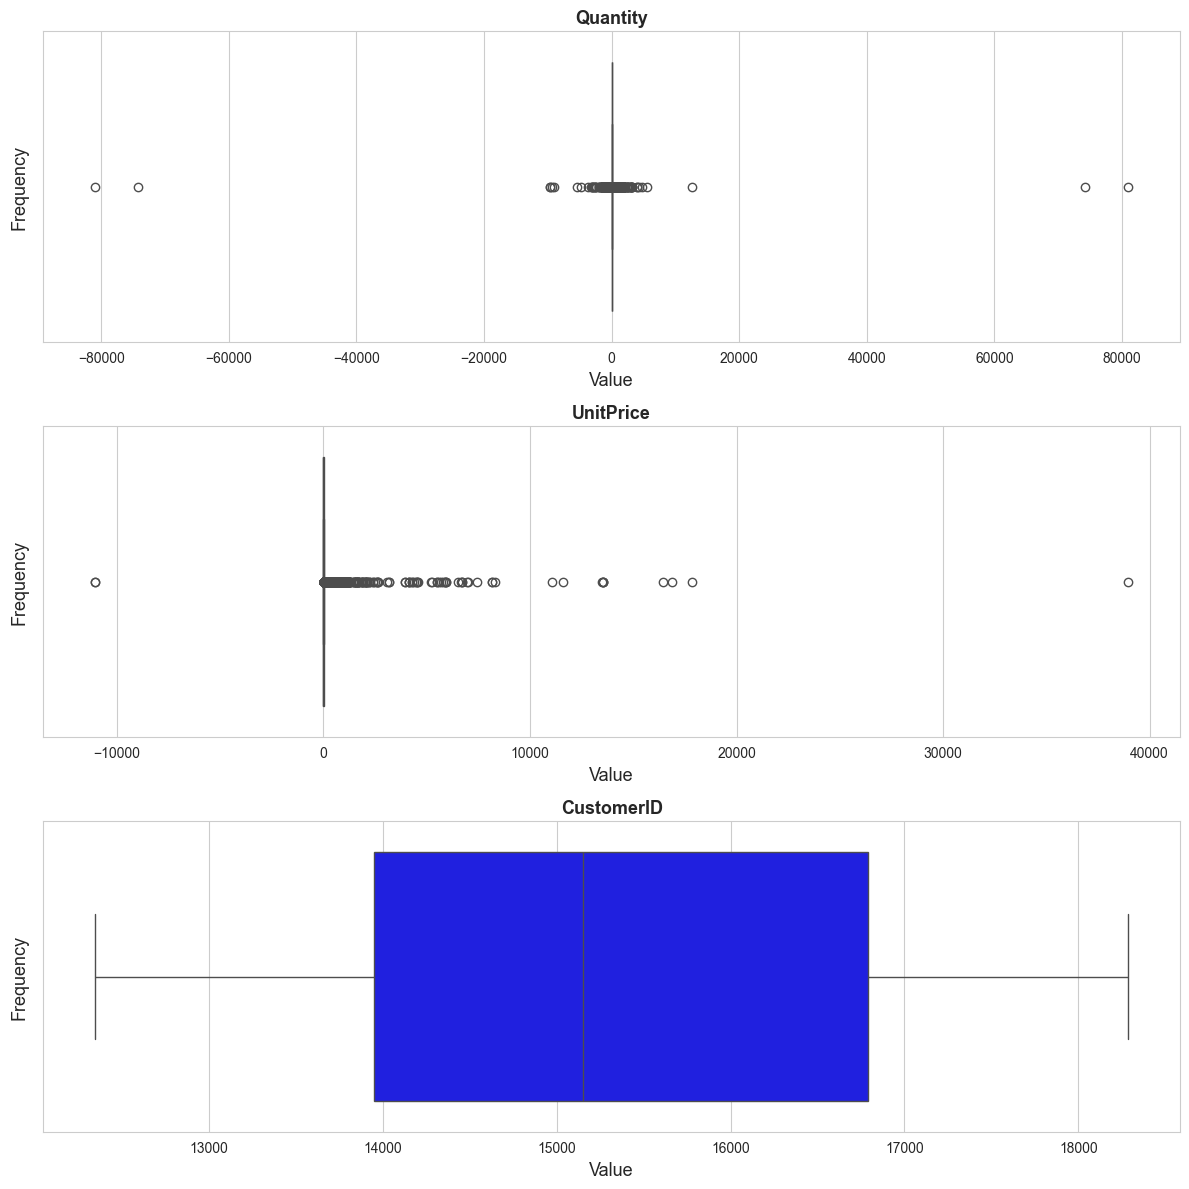

In [8]:
# Menampilkan Box Plot kolom numeric
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_vars = df[numerical_cols].shape[1]

n_cols = 1
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(df[numerical_cols].columns):
    sns.boxplot(x=df[column], ax=axes[i], color='blue')
    axes[i].set_title(column, fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

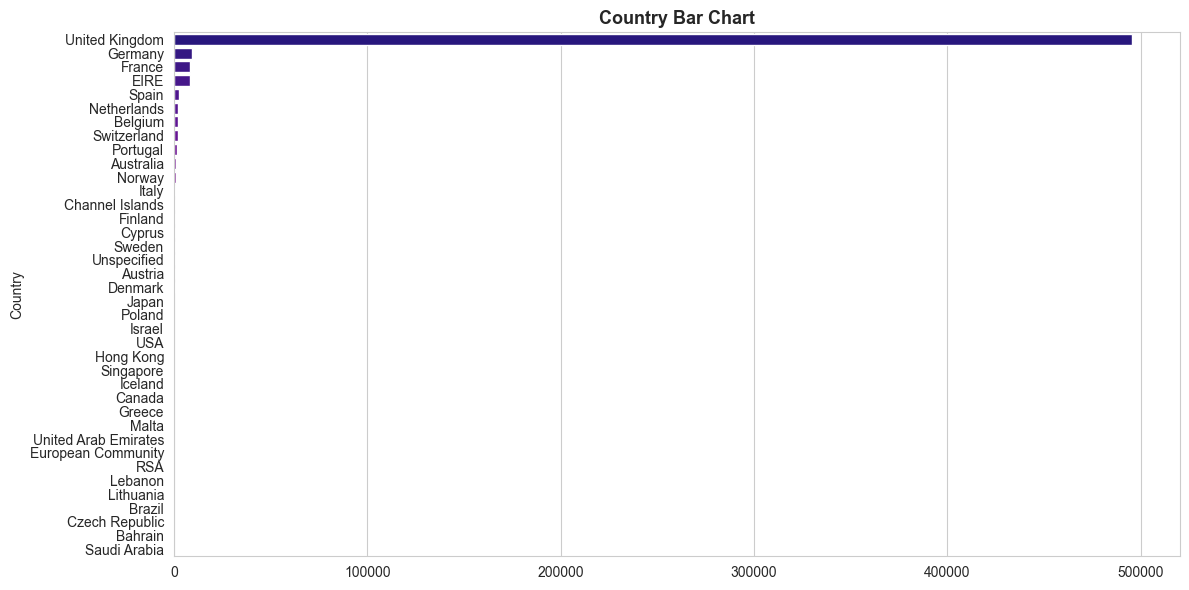

In [9]:
# Menampilkan Bar Chart persebaran kolom Country
country = df['Country'].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.barplot(x=country.values, y=country.index, palette='plasma', hue=country.index)
ax.set_title('Country Bar Chart', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [10]:
df_lencoder = df.copy()
categorical_cols = df.select_dtypes(include=['object']).columns

for column in df_lencoder[categorical_cols].columns:
    label_encoder = LabelEncoder()
    df_lencoder[column] = label_encoder.fit_transform(df_lencoder[column].astype(str))

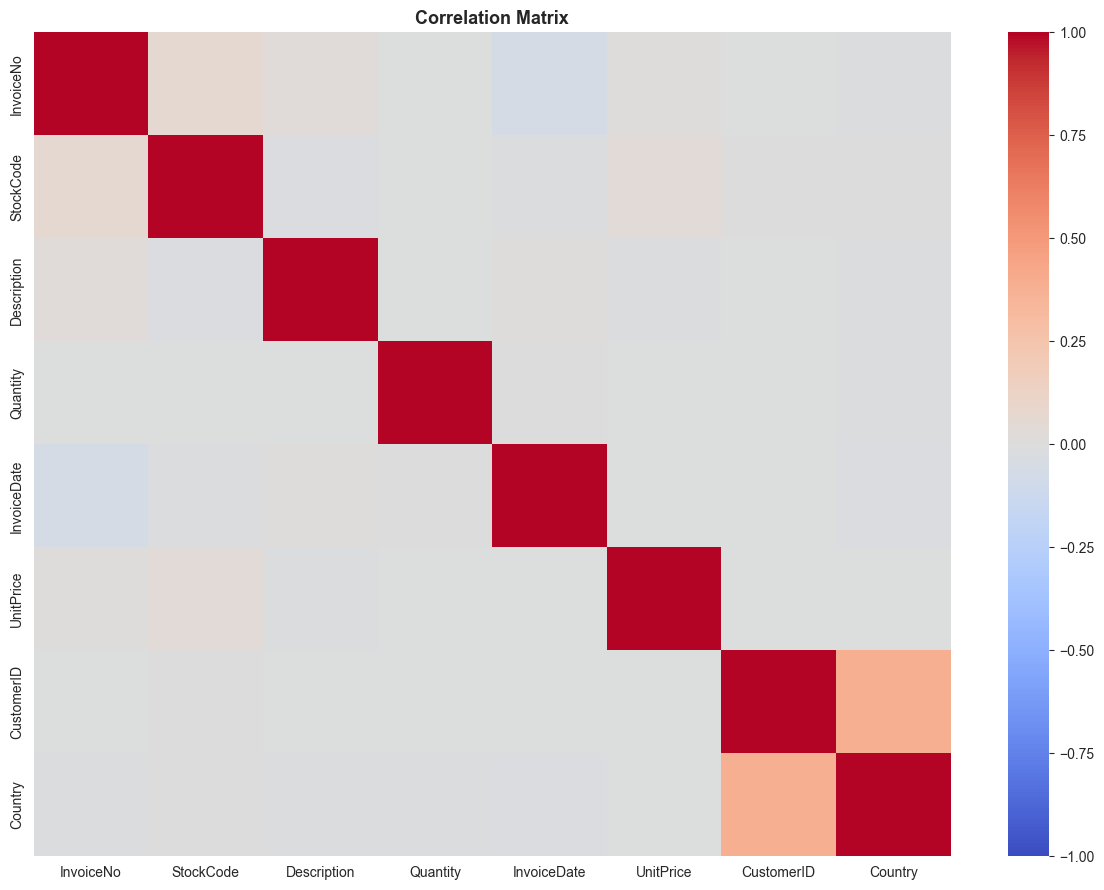

In [11]:
# Menampilkan Heatmap korelasi antar data
correlation_matrix = df_lencoder.corr()

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

sns.heatmap(data=correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Matrix', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

# **Pre-processing**

## Raw Data

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [15]:
df.dropna(inplace=True)
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
# Memperbaiki format data masing-masing kolom
categorical_cols = ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Country']
numerical_cols = ['Quantity', 'UnitPrice']

for column in categorical_cols:
    df[column] = df[column].astype(str)

for column in numerical_cols:
    df[column] = df[column].astype(float)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [17]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,401604,401604,401604,401604.000000,401604,401604.000000,401604,401604
unique,22190,3684,3896,NaN,NaN,NaN,4372,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom
freq,542,2065,2058,NaN,NaN,NaN,7812,356728
mean,NaN,NaN,NaN,12.183273,2011-07-10 12:08:23.848567552,3.474064,NaN,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,0.000000,NaN,NaN
25%,NaN,NaN,NaN,2.000000,2011-04-06 15:02:00,1.250000,NaN,NaN
50%,NaN,NaN,NaN,5.000000,2011-07-29 15:40:00,1.950000,NaN,NaN
75%,NaN,NaN,NaN,12.000000,2011-10-20 11:58:30,3.750000,NaN,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,NaN,NaN


In [18]:
min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,4.25,17850.0,United Kingdom


In [19]:
max_date = df['InvoiceDate'].max()
df[df['InvoiceDate'] == max_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12.0,2011-12-09 12:50:00,1.65,12680.0,France
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12.0,2011-12-09 12:50:00,1.65,12680.0,France
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4.0,2011-12-09 12:50:00,3.75,12680.0,France
541898,581587,22727,ALARM CLOCK BAKELIKE RED,4.0,2011-12-09 12:50:00,3.75,12680.0,France
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4.0,2011-12-09 12:50:00,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4.0,2011-12-09 12:50:00,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8.0,2011-12-09 12:50:00,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12.0,2011-12-09 12:50:00,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4.0,2011-12-09 12:50:00,4.15,12680.0,France


In [20]:
# Menghapus transaksi sebelum tahun 2010 bulan 12 tanggal 9 jam 13:00 agar total Bulan seimbang
start_date = "2010-12-09 13:00:00"

df.drop(df[df['InvoiceDate'] < start_date].index, inplace=True)

min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
20250,538035,84341B,SMALL PINK MAGIC CHRISTMAS TREE,1.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20251,538035,22566,FELTCRAFT HAIRBAND PINK AND PURPLE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20252,538035,22565,FELTCRAFT HAIRBANDS PINK AND WHITE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20253,538035,22586,FELTCRAFT HAIRBAND PINK AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20254,538035,22587,FELTCRAFT HAIRBAND RED AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
...,...,...,...,...,...,...,...,...
20318,538035,21429,RED GINGHAM ROSE JEWELLERY BOX,2.0,2010-12-09 13:03:00,1.65,16065.0,United Kingdom
20319,538035,20728,LUNCH BAG CARS BLUE,3.0,2010-12-09 13:03:00,1.65,16065.0,United Kingdom
20321,538035,22644,CERAMIC CHERRY CAKE MONEY BANK,4.0,2010-12-09 13:03:00,1.45,16065.0,United Kingdom
20322,538035,22176,BLUE OWL SOFT TOY,4.0,2010-12-09 13:03:00,2.95,16065.0,United Kingdom


In [21]:
# Menghapus transaksi di luar United Kingdom
df.drop(df[df['Country'] != 'United Kingdom'].index, inplace=True)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
20250,538035,84341B,SMALL PINK MAGIC CHRISTMAS TREE,1.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20251,538035,22566,FELTCRAFT HAIRBAND PINK AND PURPLE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20252,538035,22565,FELTCRAFT HAIRBANDS PINK AND WHITE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20253,538035,22586,FELTCRAFT HAIRBAND PINK AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
20254,538035,22587,FELTCRAFT HAIRBAND RED AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8.0,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


### Feature Engineering


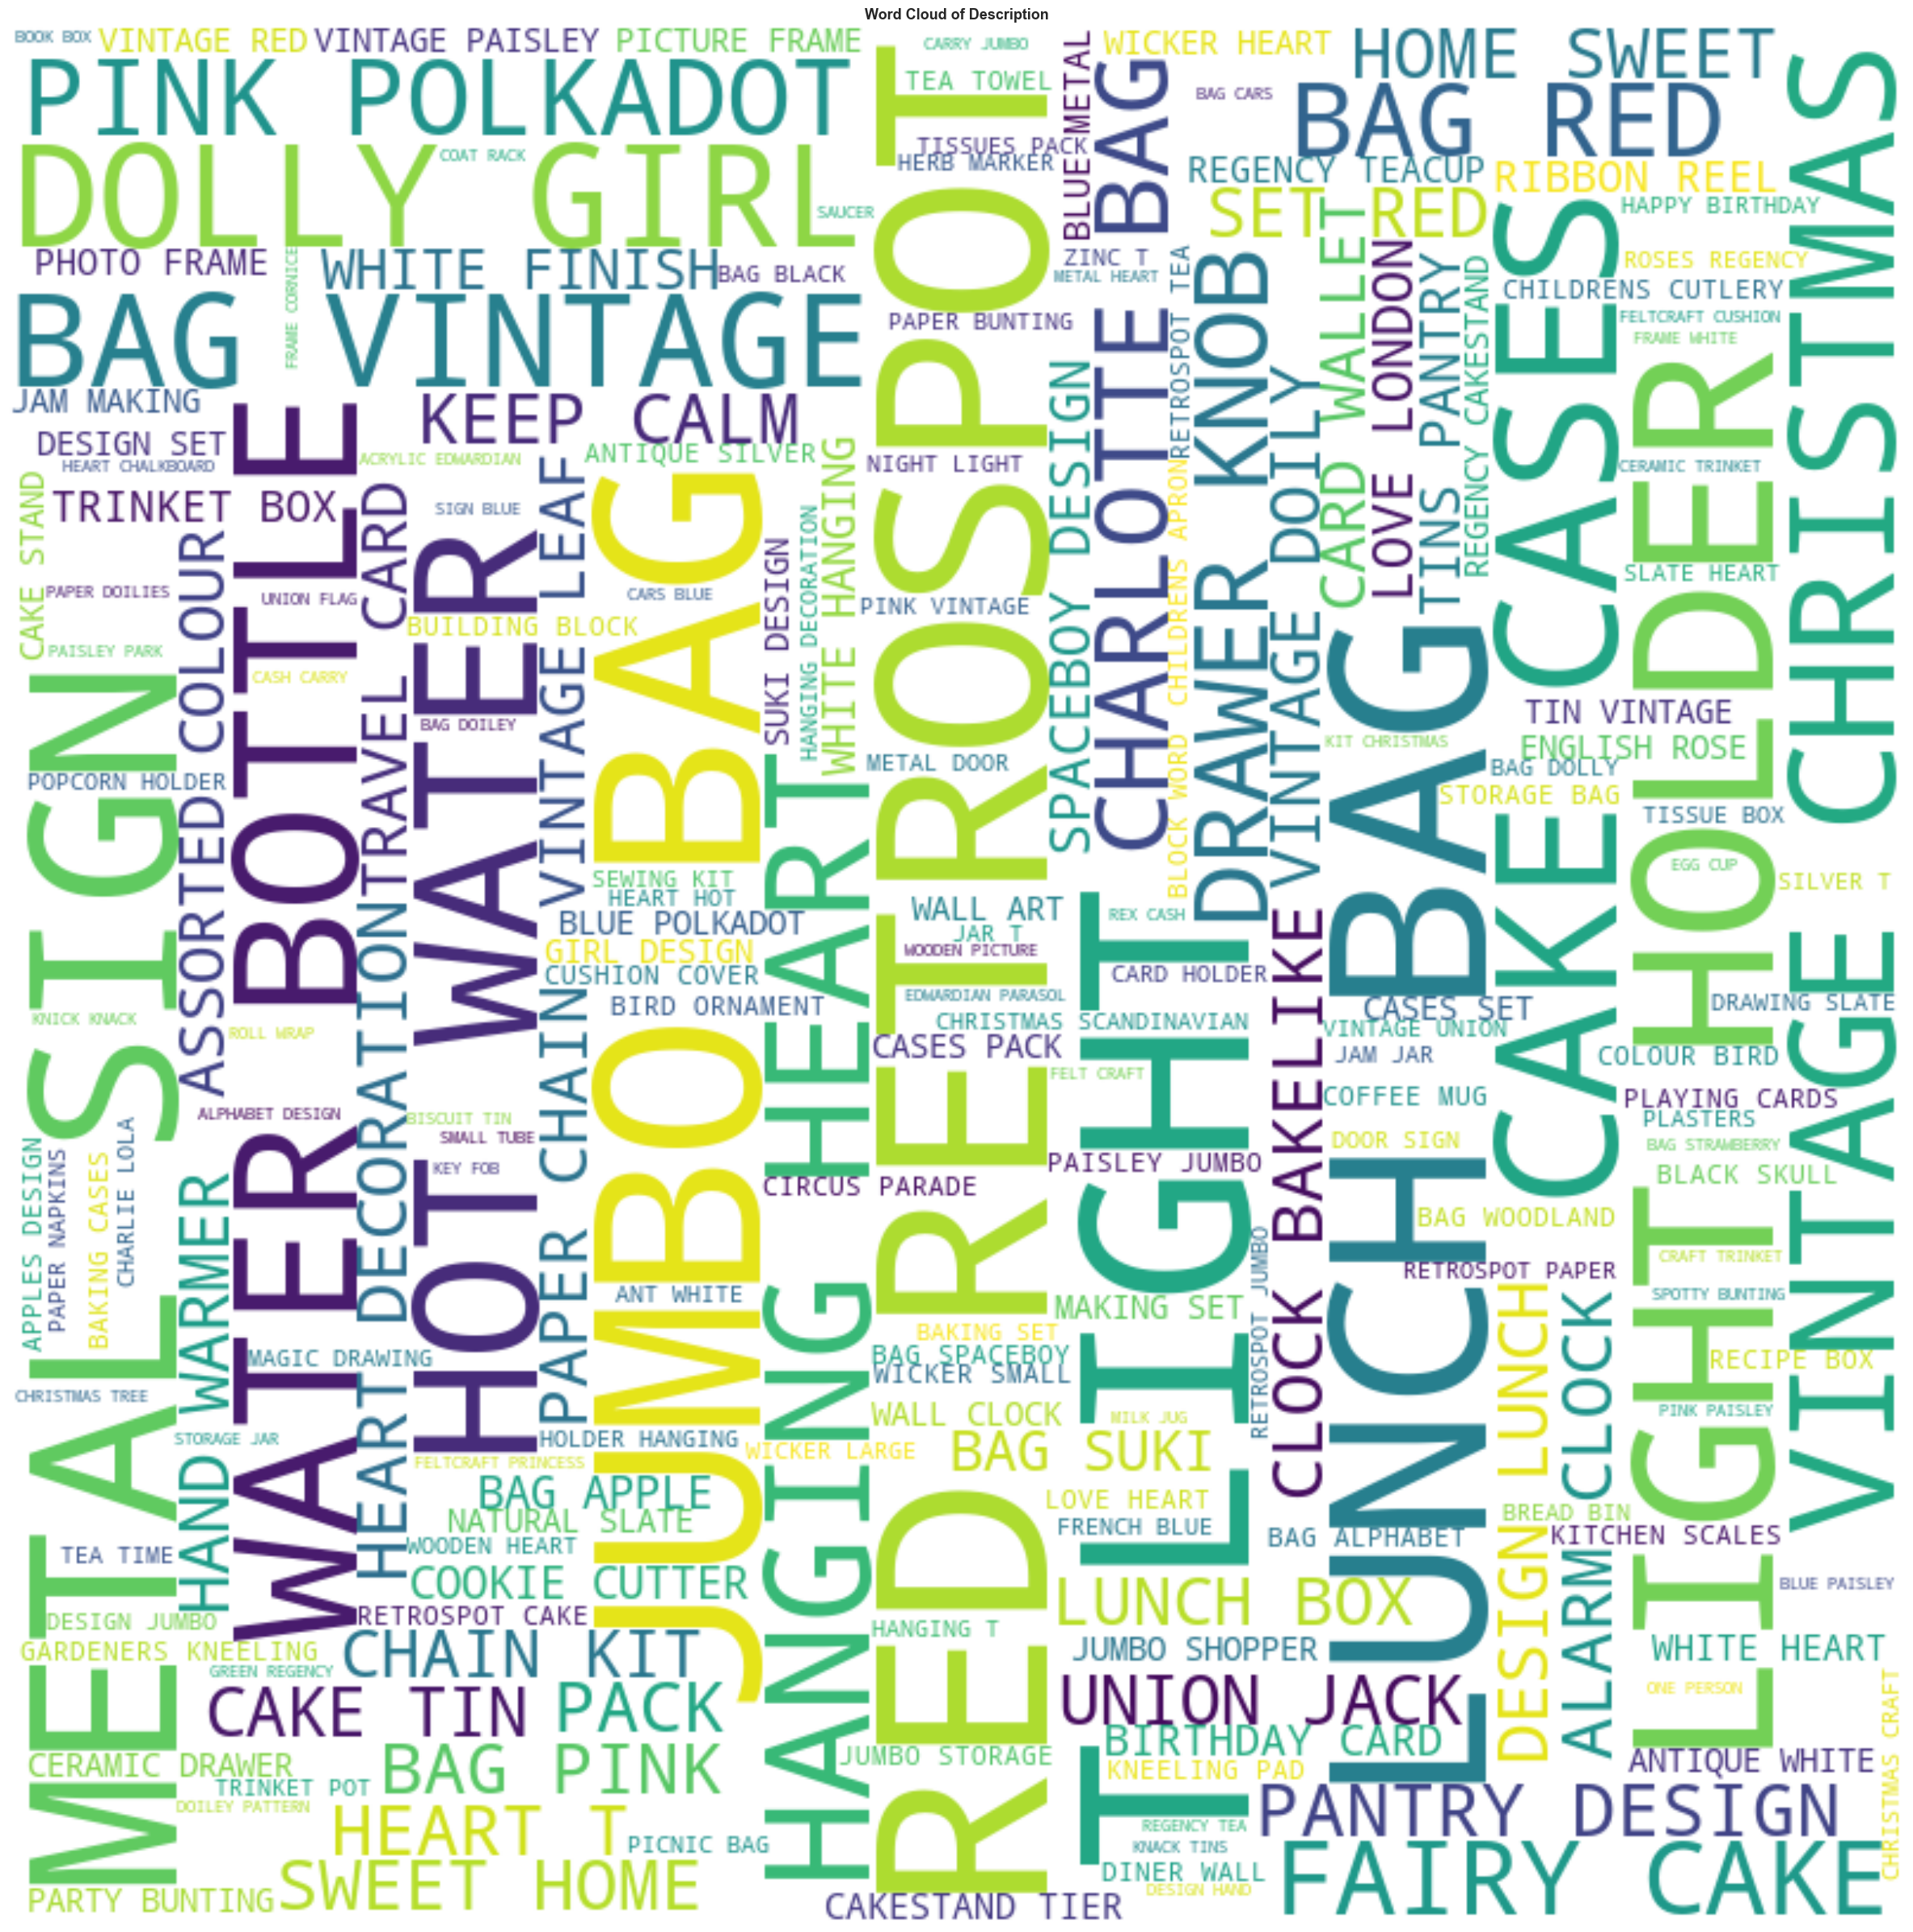

In [22]:
# Menampilkan WordCloud kolom Description
list_text = ' '.join(df['Description'])
wc = WordCloud(width=800, height=800, background_color='white').generate(list_text)

fig, ax = plt.subplots(1, 1, figsize=(24, 24))

ax.imshow(wc, interpolation='bilinear')
ax.set_title(f'Word Cloud of Description', fontsize=13, weight='bold')
ax.axis('off')

fig.tight_layout()
plt.show()

In [23]:
# Mengelompokkan kata-kata dalam deskripsi ke dalam dictionary
dict_category = {
    'bags': [
        'bag', 'shopper', 'tote', 'lunch', 'jumbo bag',
        'satchel', 'handbag', 'travel bag'
    ],

    'kitchen': [
        'mug', 'cup', 'teacup', 'plate', 'bowl', 'dish',
        'bottle', 'water bottle', 'pantry', 'jug', 'milk jug',
        'teapot', 'napkin', 'coaster', 'tray', 'cutlery',
        'bread bin', 'egg cup', 'salt', 'pepper', 'kitchen'
    ],

    'decoration': [
        'heart', 'hanging', 'ornament', 'frame', 'photo frame',
        'sign', 'door sign', 'wall art', 'decoration',
        'doorstop', 'cushion', 'mirror', 'vase', 'bunting',
        'union jack', 'sweet home', 'love'
    ],

    'lighting': [
        'light', 't light', 'tlight', 'lantern', 'candle',
        'lamp', 'led', 'night light', 'fairy light', 'tea light'
    ],

    'christmas': [
        'christmas', 'xmas', 'santa', 'snowman', 'reindeer',
        'advent', 'stocking', 'tree decoration', 'bauble'
    ],

    'storage': [
        'box', 'tin', 'jar', 'basket', 'case', 'cases',
        'container', 'storage', 'trinket', 'recipe box',
        'tissue box', 'book box', 'chest'
    ],

    'baking': [
        'cake', 'cakestand', 'cake stand', 'baking', 'cookie',
        'mould', 'fairy cake', 'cupcake', 'muffin', 'recipe'
    ],

    'stationery': [
        'card', 'birthday', 'notebook', 'paper', 'wrap',
        'ribbon', 'tag', 'pen', 'pencil', 'gift'
    ],

    'clocks': [
        'clock', 'alarm', 'wall clock', 'alarm clock', 'watch'
    ],

    'garden': [
        'garden', 'plant', 'pot', 'flower', 'seed',
        'herb', 'watering', 'bird'
    ],

    'kids': [
        'spaceboy', 'dolly', 'fairy', 'childrens', 'children',
        'kids', 'girl', 'boy', 'toy', 'doll', 'teddy', 'baby'
    ],

    'furniture': [
        'drawer', 'knob', 'handle', 'hook', 'hanger',
        'coat', 'door', 'cabinet'
    ]
}

def category_map(desc):
    desc = str(desc).lower()

    for category, keywords in dict_category.items():
        for item in keywords:
            if item in desc:
                return category
    return 'others'

In [24]:
# Membuat kolom Category
df['Category'] = df['Description'].apply(category_map)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category
20250,538035,84341B,SMALL PINK MAGIC CHRISTMAS TREE,1.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,christmas
20251,538035,22566,FELTCRAFT HAIRBAND PINK AND PURPLE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others
20252,538035,22565,FELTCRAFT HAIRBANDS PINK AND WHITE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others
20253,538035,22586,FELTCRAFT HAIRBAND PINK AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others
20254,538035,22587,FELTCRAFT HAIRBAND RED AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8.0,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,decoration
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage


In [25]:
# Mengelompokkan Bulan transaksi ke dalam kolom Seasonality
seasons = {
    'Spring': [3,4,5],
    'Summer': [6,7,8],
    'Fall': [9,10,11],
    'Winter': [12,1,2]
}

for season, months in seasons.items():
    df.loc[df['InvoiceDate'].dt.month.isin(months), 'Seasonality'] = season

df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality
339451,566595,84992,72 SWEETHEART FAIRY CAKE CASES,600.0,2011-09-13 15:03:00,0.42,18251.0,United Kingdom,decoration,Fall
389512,570479,22554,PLASTERS IN TIN WOODLAND ANIMALS,3.0,2011-10-10 16:58:00,1.65,17589.0,United Kingdom,storage,Fall
186918,552888,22423,REGENCY CAKESTAND 3 TIER,120.0,2011-05-12 10:23:00,10.95,15061.0,United Kingdom,baking,Spring
55891,541005,21563,RED HEART SHAPE LOVE BUCKET,3.0,2011-01-13 10:39:00,2.95,16161.0,United Kingdom,decoration,Winter
428724,573496,23348,CHILDRENS TOY COOKING UTENSIL SET,4.0,2011-10-31 11:59:00,2.08,17841.0,United Kingdom,kids,Fall
498048,578508,23269,SET OF 2 CERAMIC CHRISTMAS TREES,2.0,2011-11-24 13:06:00,1.45,16892.0,United Kingdom,christmas,Fall
475899,576924,47590B,PINK HAPPY BIRTHDAY BUNTING,3.0,2011-11-17 10:53:00,5.45,17419.0,United Kingdom,decoration,Fall
289307,562263,84971S,SMALL HEART FLOWERS HOOK,5.0,2011-08-03 15:45:00,0.85,17514.0,United Kingdom,decoration,Summer
463451,576062,23308,SET OF 60 VINTAGE LEAF CAKE CASES,5.0,2011-11-13 15:30:00,0.55,12867.0,United Kingdom,storage,Fall
101447,544918,21497,FANCY FONTS BIRTHDAY WRAP,25.0,2011-02-24 16:30:00,0.42,13081.0,United Kingdom,stationery,Winter


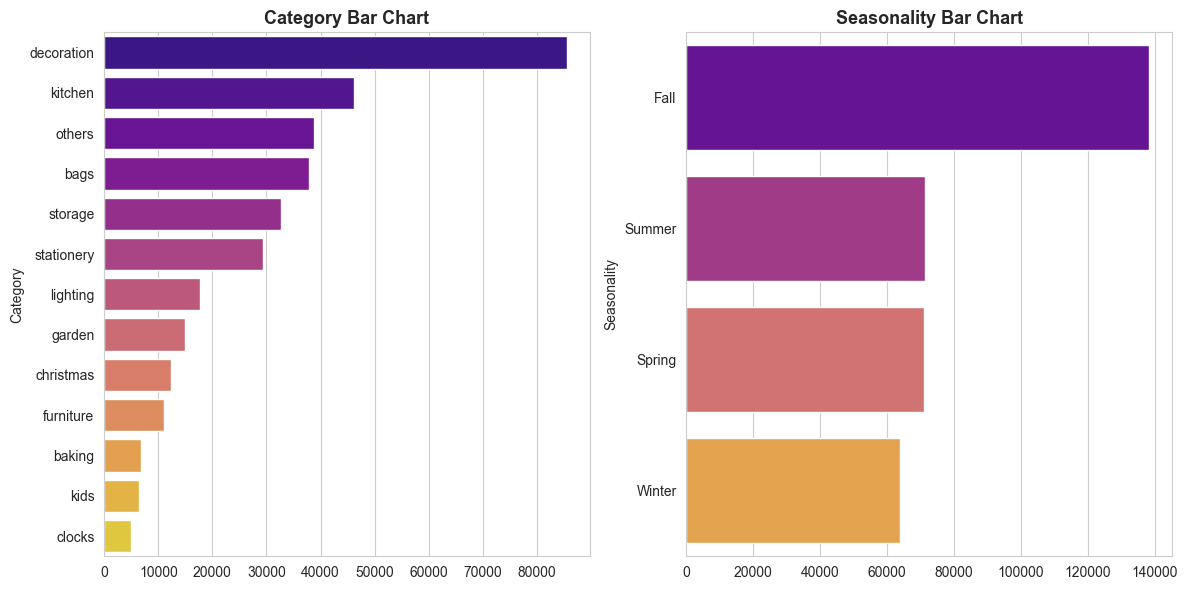

In [26]:
# Menampilkan Bar Chart persebaran Category dan Seasonality
new_features = {
    'Category': df['Category'].value_counts(),
    'Seasonality': df['Seasonality'].value_counts()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, (key, item) in enumerate(new_features.items()):
    sns.barplot(x=item.values, y=item.index, ax=axes[i], palette='plasma', hue=item.index, legend=False)
    axes[i].set_title(f'{key} Bar Chart', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [27]:
# Menghitung Monetary dengan kolom Sales
df['Sales'] = df['Quantity'] * df['UnitPrice']

df.sort_values(by='Sales', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995.0,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,stationery,Winter,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,storage,Winter,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60.0,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,storage,Summer,38970.00
173382,551697,POST,POSTAGE,1.0,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,stationery,Spring,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412.0,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,kitchen,Fall,7144.72
...,...,...,...,...,...,...,...,...,...,...,...
173391,C551699,M,Manual,-1.0,2011-05-03 14:12:00,6930.00,16029.0,United Kingdom,others,Spring,-6930.00
173277,C551685,POST,POSTAGE,-1.0,2011-05-03 12:51:00,8142.75,16029.0,United Kingdom,stationery,Spring,-8142.75
222681,C556445,M,Manual,-1.0,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,others,Summer,-38970.00
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215.0,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,storage,Winter,-77183.60


In [28]:
# Menghapus transaksi custonmer yang diretur
retur = (df.loc[df['Sales'] <= 0, 'CustomerID'] + '_' + df.loc[df['Sales'] <= 0, 'StockCode']) 

df = df[~(df['CustomerID'] + '_' + df['StockCode']).isin(retur)] 

df.sort_values(by='Sales', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412.0,2011-09-20 11:05:00,5.060,17450.0,United Kingdom,kitchen,Fall,7144.720
244419,558526,23173,REGENCY TEAPOT ROSES,540.0,2011-06-30 11:01:00,8.150,17949.0,United Kingdom,kitchen,Summer,4401.000
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880.0,2011-08-04 18:06:00,1.450,12931.0,United Kingdom,decoration,Summer,4176.000
533812,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404.0,2011-12-07 12:20:00,2.750,15195.0,United Kingdom,decoration,Winter,3861.000
348323,567423,22722,SET OF 6 SPICE TINS PANTRY DESIGN,852.0,2011-09-20 11:05:00,4.250,17450.0,United Kingdom,kitchen,Fall,3621.000
...,...,...,...,...,...,...,...,...,...,...,...
500313,578757,16216,LETTER SHAPE PENCIL SHARPENER,1.0,2011-11-25 11:41:00,0.060,12748.0,United Kingdom,stationery,Fall,0.060
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2011-07-26 10:13:00,0.001,15618.0,United Kingdom,decoration,Summer,0.001
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,decoration,Fall,0.001
361741,568375,BANK CHARGES,Bank Charges,1.0,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,others,Fall,0.001


## RFM

In [29]:
# Membuat kolom RFM
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

Recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days)
Frequency = ('InvoiceNo', 'nunique')
Monetary = ('Sales', 'sum')

In [30]:
# Membuat df RFM
df_rfm = df.groupby('CustomerID').agg(
    Recency=Recency,
    Frequency=Frequency,
    Monetary=Monetary
).reset_index()

df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12747.0,2,10,3837.45
1,12748.0,1,184,27025.84
2,12749.0,4,4,2916.51
3,12820.0,3,4,942.34
4,12821.0,214,1,92.72
...,...,...,...,...
3830,18280.0,278,1,180.60
3831,18281.0,181,1,80.82
3832,18282.0,8,2,164.13
3833,18283.0,4,16,2045.53


In [31]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  3835 non-null   object 
 1   Recency     3835 non-null   int64  
 2   Frequency   3835 non-null   int64  
 3   Monetary    3835 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 120.0+ KB


In [32]:
df_rfm.describe(include='all')

,CustomerID,Recency,Frequency,Monetary
count,3835,3835.000000,3835.000000,3835.000000
unique,3835,NaN,NaN,NaN
top,12747.0,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,87.842243,4.061799,1563.341435
std,NaN,93.978293,6.622198,5832.237728
min,NaN,1.000000,1.000000,2.900000
25%,NaN,17.000000,1.000000,281.495000
50%,NaN,50.000000,2.000000,620.400000
75%,NaN,134.000000,4.000000,1479.860000


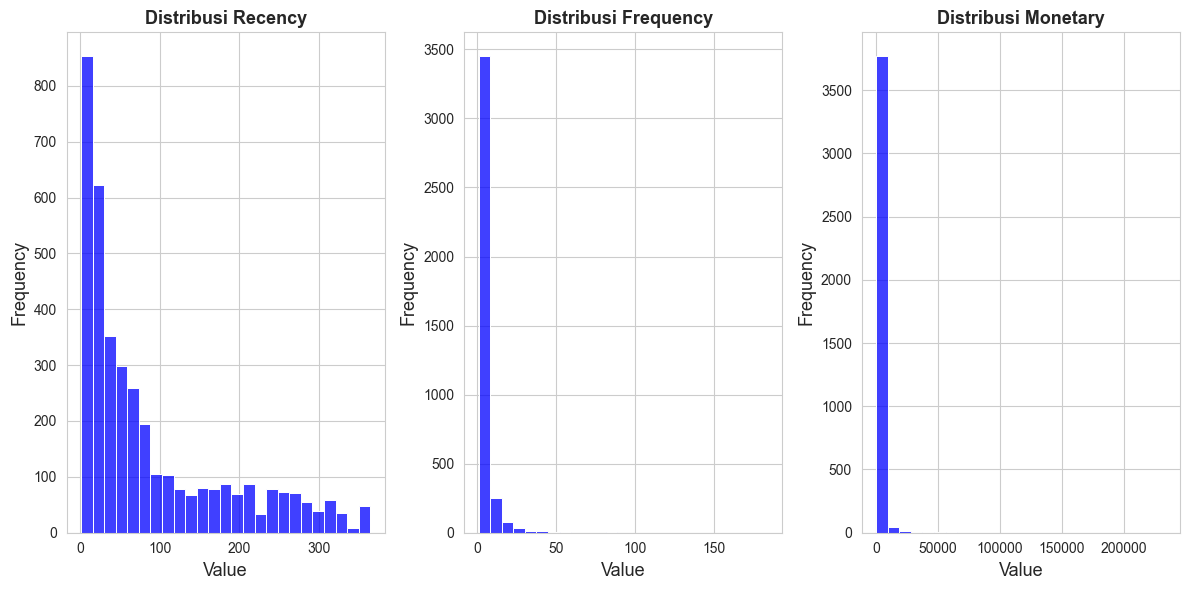

In [33]:
# Menampilkan Bar Chart kolom RFM
columns = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(columns):
  sns.histplot(data=df_rfm[column], bins=25, color='blue', ax=axes[i])
  axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
  axes[i].set_xlabel('Value', fontsize=13)
  axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

In [34]:
# Menerapkan Log Transformation
df_rfm_log = df_rfm.copy()
df_rfm_log[columns] = np.log1p(df_rfm_log[columns])

df_rfm_log.head()

,CustomerID,Recency,Frequency,Monetary
0,12747.0,1.098612,2.397895,8.252824
1,12748.0,0.693147,5.220356,10.204586
2,12749.0,1.609438,1.609438,7.978486
3,12820.0,1.386294,1.609438,6.849427
4,12821.0,5.370638,0.693147,4.540312


In [35]:
# Menerapkan Standarization
df_rfm_scaled = df_rfm_log.copy()

scaler = RobustScaler()
df_rfm_scaled[columns] = scaler.fit_transform(df_rfm_scaled[columns])

df_rfm_scaled.head()

,CustomerID,Recency,Frequency,Monetary
0,12747.0,-1.406129,1.417981,1.099071
1,12748.0,-1.607362,4.498292,2.277162
2,12749.0,-1.152605,0.557493,0.933480
3,12820.0,-1.263352,0.557493,0.251975
4,12821.0,0.714085,-0.442507,-1.141815


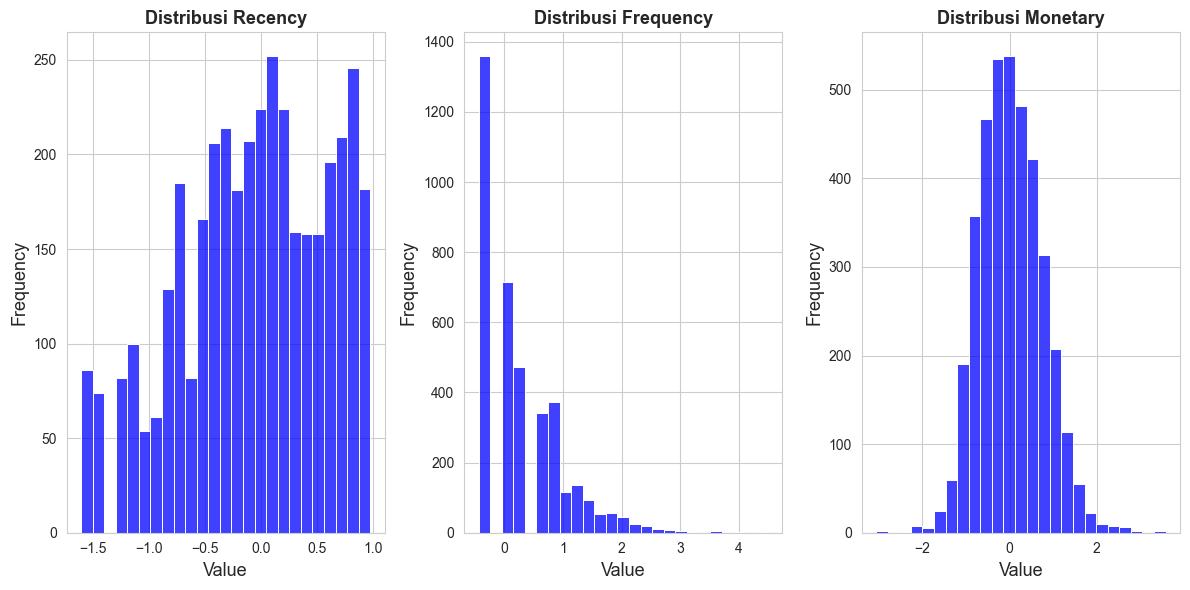

In [36]:
# Menampilkan Bar Chart kolom RFM setelah Log Transformation dan Standarization
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(columns):
    sns.histplot(data=df_rfm_scaled[column], bins=25, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

In [37]:
# Melakukan Binning pada kolom Frequency
bin_columns = ['Recency', 'FrequencyBin', 'Monetary']
bins = [-np.inf, 0, 1, 2, np.inf]
bin_labels = ['Low', 'Medium', 'High', 'Very High']

df_rfm_binned = df_rfm_scaled.copy()
df_rfm_binned['FrequencyBin'] = pd.cut(df_rfm_binned['Frequency'], bins=bins, labels=bin_labels)

le = LabelEncoder()
df_rfm_binned['FrequencyBin'] = le.fit_transform(df_rfm_binned['FrequencyBin'])

df_rfm_binned.head()

,CustomerID,Recency,Frequency,Monetary,FrequencyBin
0,12747.0,-1.406129,1.417981,1.099071,0
1,12748.0,-1.607362,4.498292,2.277162,3
2,12749.0,-1.152605,0.557493,0.933480,2
3,12820.0,-1.263352,0.557493,0.251975,2
4,12821.0,0.714085,-0.442507,-1.141815,1


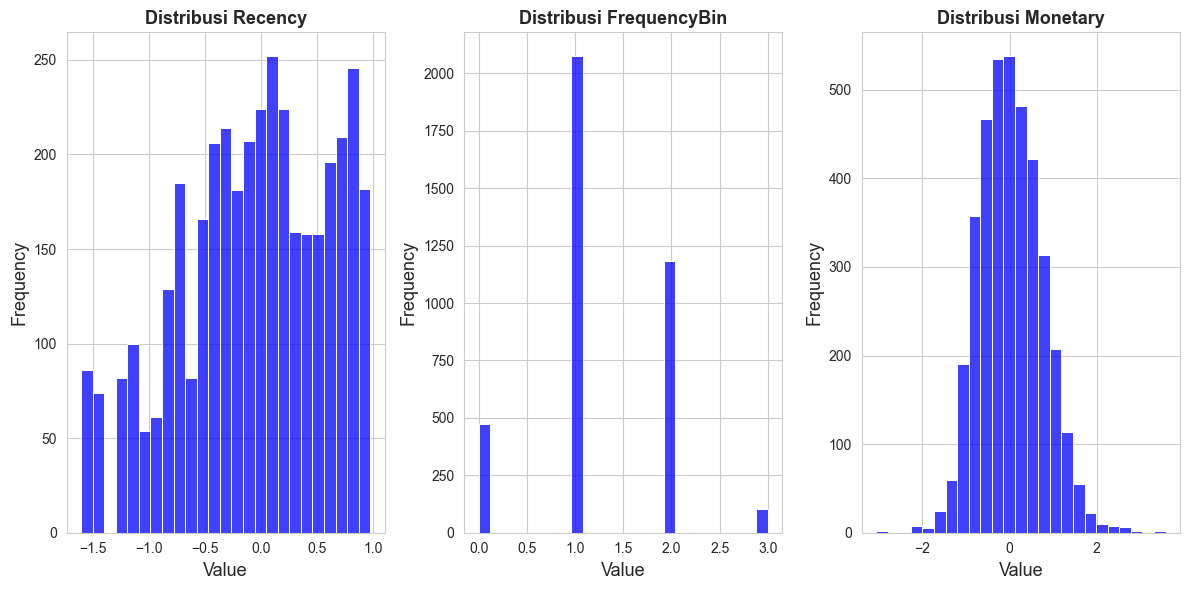

In [38]:
# Menampilkan Bar Chart kolom RFM setelah Binnning
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(bin_columns):
    sns.histplot(data=df_rfm_binned[column], bins=25, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

# **Clustering**

## KMeans++

In [39]:
# Mencari best param model KMeans++
X_model = df_rfm_binned[bin_columns].values
kmeans = KMeans()

for n_clusters in range(3, 6):
    kmeans.set_params(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_model)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_clusters = 3, silhouette_score: 0.4589815653991305, calinski_score: 2742.710075522392, davies_score, 0.8337225508940724
n_clusters = 4, silhouette_score: 0.37591983492842584, calinski_score: 2580.0517411495457, davies_score, 0.9632746736258049
n_clusters = 5, silhouette_score: 0.3879197786644617, calinski_score: 2623.8625855073633, davies_score, 0.9887654699642736


In [40]:
# Membuat fungsi analisa cluster
def analyze_clusters(X, labels, n):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(n):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mode_frequency = stats.mode(cluster_data[:, 1], keepdims=False)[0]
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Modus (mode) Frequency: {mode_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

In [41]:
# Menganalisa hasil clustering KMeans++
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_model)
labels = kmeans.labels_

df_kmeans = df_rfm.copy()
df_kmeans['Cluster'] = labels

analyze_clusters(X_model, labels, k)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.27837833041396237
Modus (mode) Frequency: 1.0
Rata-rata (mean) Monetary: -0.4637964858843781

Cluster 2:
Rata-rata (mean) Recency: -0.6712895776811071
Modus (mode) Frequency: 0.0
Rata-rata (mean) Monetary: 0.8166911266238575

Cluster 3:
Rata-rata (mean) Recency: -0.3679624178027734
Modus (mode) Frequency: 2.0
Rata-rata (mean) Monetary: 0.4911955306393769

Silhouette Score: 0.4589815653991305


In [42]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_kmeans['Recency'],
    y= df_kmeans['Frequency'],
    z= df_kmeans['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_kmeans['Cluster'],
        size= 12,
        line=dict(
            color= df_kmeans['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D KMeans++',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show()

PCA KMeans++

In [43]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans_pca.fit(df_PCA)

labels = kmeans_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5824128652630904


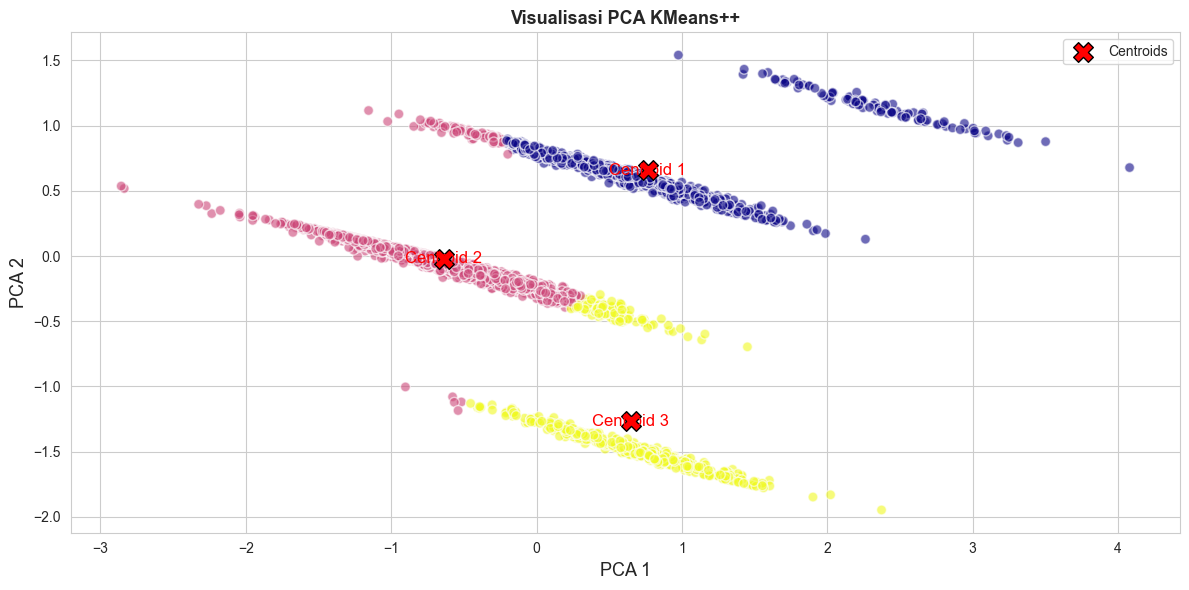


Nilai Centroids:
Centroid 1: PCA 1 = 0.77, PCA 2 = 0.66
Centroid 2: PCA 1 = -0.64, PCA 2 = -0.02
Centroid 3: PCA 1 = 0.65, PCA 2 = -1.27


In [44]:
# Menampilkan visualisasi 2D dari hasil Clustering
centroids = kmeans_pca.cluster_centers_

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA KMeans++', fontsize=13, weight='bold')
ax.legend()
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## Spectral Clustering

In [45]:
# Mencari best param model Spectral
X_model = df_rfm_binned[bin_columns].values
spectral = SpectralClustering()

for n_clusters in range(3, 6):
    spectral.set_params(n_clusters=n_clusters)
    spectral.fit(X_model)
    labels = spectral.labels_

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_clusters = 3, silhouette_score: 0.41675922833707685, calinski_score: 1177.26035967095, davies_score, 0.6892394736555413
n_clusters = 4, silhouette_score: 0.39177282984746714, calinski_score: 774.7414250478998, davies_score, 0.8572625065006201
n_clusters = 5, silhouette_score: 0.4304604259821118, calinski_score: 1654.480365223481, davies_score, 0.8735327049268997


In [46]:
# Menganalisa hasil clustering Spectral
s = 5
spectral = SpectralClustering(n_clusters=s)
spectral.fit(X_model)
labels = spectral.labels_

df_spectral = df_rfm.copy()
df_spectral['Cluster'] = labels

analyze_clusters(X_model, labels, s)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.21660880470321936
Modus (mode) Frequency: 1.0
Rata-rata (mean) Monetary: -0.42903411303720945

Cluster 2:
Rata-rata (mean) Recency: -1.3187176104492928
Modus (mode) Frequency: 3.0
Rata-rata (mean) Monetary: 2.4543030799655914

Cluster 3:
Rata-rata (mean) Recency: -0.6973915801268074
Modus (mode) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9820506698796807

Cluster 4:
Rata-rata (mean) Recency: -0.26960739970319886
Modus (mode) Frequency: 2.0
Rata-rata (mean) Monetary: 0.38320514051088034

Cluster 5:
Rata-rata (mean) Recency: -1.187583296154557
Modus (mode) Frequency: 3.0
Rata-rata (mean) Monetary: 1.5721093878270695

Silhouette Score: 0.4302616740733766


In [47]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_spectral['Recency'],
    y= df_spectral['Frequency'],
    z= df_spectral['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_spectral['Cluster'],
        size= 12,
        line=dict(
            color= df_spectral['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D Spectral',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show()

PCA Spectral

In [48]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

spectral_pca = SpectralClustering(n_clusters=s)
spectral_pca.fit(X_model)
labels = spectral_pca.labels_

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5597391468700937


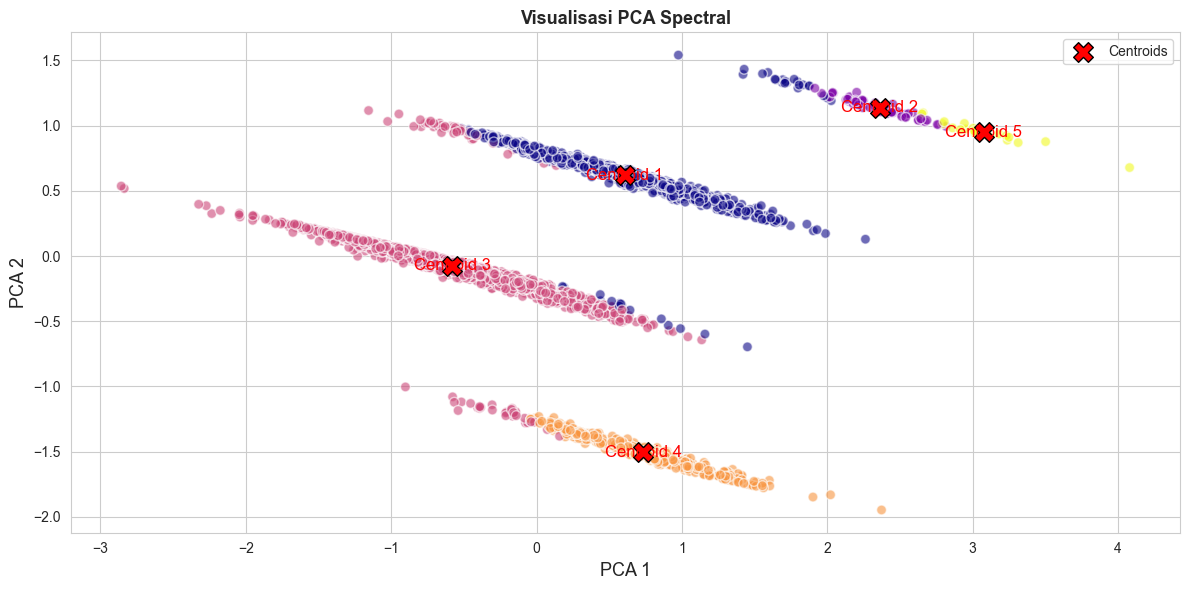


Nilai Centroids:
Centroid 1: PCA 1 = 0.61, PCA 2 = 0.62
Centroid 2: PCA 1 = 2.36, PCA 2 = 1.14
Centroid 3: PCA 1 = -0.58, PCA 2 = -0.07
Centroid 4: PCA 1 = 0.73, PCA 2 = -1.50
Centroid 5: PCA 1 = 3.08, PCA 2 = 0.95


In [49]:
# Menampilkan visualisasi 2D dari hasil Clustering
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

unique_labels = set(labels)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
ax.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA Spectral', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## GMM

In [50]:
# Mencari best param model GMM
X_model = df_rfm_binned[bin_columns].values
gmm = GaussianMixture()

for n_components in range(3, 6):
    gmm.set_params(n_components=n_components)
    gmm.fit(X_model)
    labels = gmm.predict(X_model)

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_components = {n_components}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_components = 3, silhouette_score: 0.4506210708313838, calinski_score: 2568.920939871975, davies_score, 0.8556159605142409
n_components = 4, silhouette_score: 0.3381369613451767, calinski_score: 2262.6078855250234, davies_score, 0.9601261632750571
n_components = 5, silhouette_score: 0.37194588630910924, calinski_score: 2324.206691105249, davies_score, 0.8909580350614913


In [51]:
# Menganalisa hasil clustering GMM
g = 3
gmm = GaussianMixture(n_components=g, random_state=42)
labels = gmm.fit_predict(X_model)

df_gmm = df_rfm.copy()
df_gmm['Cluster'] = labels

analyze_clusters(X_model, labels, g)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -0.6391330814883825
Modus (mode) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9358609567351435

Cluster 2:
Rata-rata (mean) Recency: 0.21113735646614631
Modus (mode) Frequency: 1.0
Rata-rata (mean) Monetary: -0.425379231317863

Cluster 3:
Rata-rata (mean) Recency: -0.30913297963909925
Modus (mode) Frequency: 2.0
Rata-rata (mean) Monetary: 0.43097415278288054

Silhouette Score: 0.4506210708313838


In [52]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_gmm['Recency'],
    y= df_gmm['Frequency'],
    z= df_gmm['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_gmm['Cluster'],
        size= 12,
        line=dict(
            color= df_gmm['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D GMM',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show()

PCA GMM

In [53]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

gmm_pca = GaussianMixture(n_components=g, random_state=42)
gmm_pca.fit(df_PCA)

labels = gmm_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5719762428737782


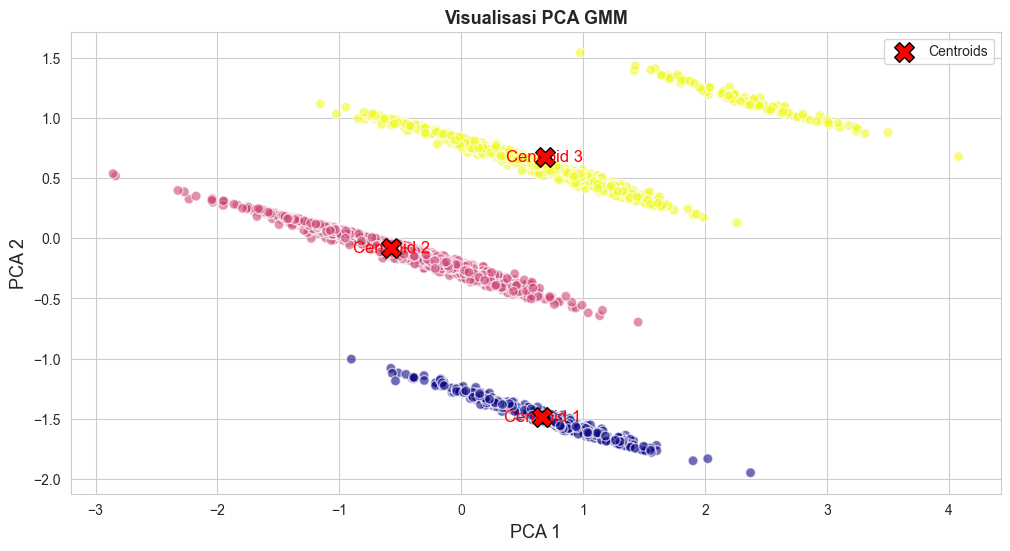


Nilai Centroids:
Centroid 1: PCA 1 = 0.67, PCA 2 = -1.48
Centroid 2: PCA 1 = -0.58, PCA 2 = -0.08
Centroid 3: PCA 1 = 0.68, PCA 2 = 0.68


In [54]:
# Menampilkan visualisasi 2D dari hasil Clustering
centroids = gmm_pca.means_ 

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA GMM', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## HDBSCAN

In [55]:
# Mencari best param model HDBSCAN
X_model = df_rfm_binned[bin_columns].values
hdb = HDBSCAN()

for n_params in range(3, 6):
    hdb.set_params(min_cluster_size=n_params, min_samples=n_params)
    labels = hdb.fit_predict(X_model)

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_params = {n_params}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_params = 3, silhouette_score: 0.08450001784144316, calinski_score: 13.91101423319997, davies_score, 1.3788791806560772
n_params = 4, silhouette_score: -0.05508373167285985, calinski_score: 25.24507825970798, davies_score, 1.3762357401330745
n_params = 5, silhouette_score: 0.43312152870838194, calinski_score: 1669.134130578733, davies_score, 0.7083245414994311


In [56]:
# Menganalisa hasil clustering HDBSCAN
h = 5
hdb = HDBSCAN(min_cluster_size=h, min_samples=h)

hdb.fit(X_model)
labels = hdb.labels_

df_hdb = df_rfm.copy()
df_hdb['Cluster'] = labels

analyze_clusters(X_model, labels, labels.max() + 1)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -1.1235907627837016
Modus (mode) Frequency: 3.0
Rata-rata (mean) Monetary: 1.6775592228395415

Cluster 2:
Rata-rata (mean) Recency: -0.6380429071166381
Modus (mode) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9318852993368568

Cluster 3:
Rata-rata (mean) Recency: 0.21113735646614631
Modus (mode) Frequency: 1.0
Rata-rata (mean) Monetary: -0.425379231317863

Cluster 4:
Rata-rata (mean) Recency: -0.23834044658939968
Modus (mode) Frequency: 2.0
Rata-rata (mean) Monetary: 0.3226211888876602

Silhouette Score: 0.43312152870838194


In [57]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_hdb['Recency'],
    y= df_hdb['Frequency'],
    z= df_hdb['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_hdb['Cluster'],
        size= 12,
        line=dict(
            color= df_hdb['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D HDBSCAN',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show()

PCA HDBCSAN

In [58]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

hdb_pca = HDBSCAN(min_cluster_size=h, min_samples=h)
hdb_pca.fit(X_model)
labels = hdb_pca.labels_

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5636121632824999


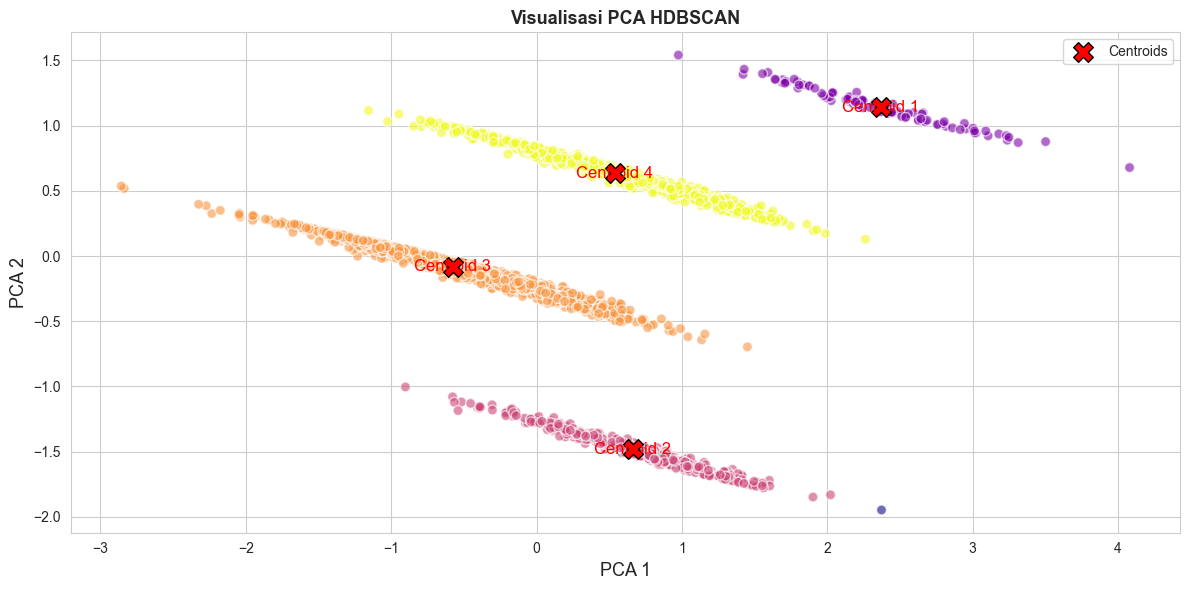


Nilai Centroids:
Centroid 1: PCA 1 = 2.37, PCA 2 = 1.14
Centroid 2: PCA 1 = 0.66, PCA 2 = -1.48
Centroid 3: PCA 1 = -0.58, PCA 2 = -0.08
Centroid 4: PCA 1 = 0.54, PCA 2 = 0.63


In [59]:
# Menampilkan visualisasi 2D dari hasil Clustering
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

unique_labels = set(labels)
unique_labels.discard(-1)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
ax.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA HDBSCAN', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

### Cluster Labeling

In [60]:
# Menghapus Cluster Outlier (-1)
df_hdb = df_hdb[df_hdb['Cluster'] != -1]
df_hdb.describe(include='all')

,CustomerID,Recency,Frequency,Monetary,Cluster
count,3834,3834.000000,3834.000000,3834.000000,3834.000000
unique,3834,NaN,NaN,NaN,NaN
top,12747.0,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,87.864111,4.058425,1546.752638,2.132499
std,NaN,93.980792,6.619763,5741.798421,0.722471
min,NaN,1.000000,1.000000,2.900000,0.000000
25%,NaN,17.000000,1.000000,281.457500,2.000000
50%,NaN,50.000000,2.000000,620.230000,2.000000
75%,NaN,134.000000,4.000000,1477.267500,3.000000


In [61]:
# Melakukan analisa cluster
cluster_analysis = df_hdb.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_scaled)) * 100)
).reset_index().sort_values(by='Cluster')

cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
0,0,6.514563,31.533981,16986.133204,103,2.685789
1,1,24.101911,10.010616,3612.710934,471,12.281617
2,2,125.522410,1.345060,428.185399,2075,54.106910
3,3,54.336709,4.055696,1342.283833,1185,30.899609


In [62]:
# Memberikan label pada cluster
cluster_label = {
    0: 'Loyal Customer',
    1: 'Regular Customer',
    2: 'Churn/One Time Spender',
    3: 'High Risk Churn'
}

cluster_analysis['Label'] = cluster_analysis['Cluster'].map(cluster_label)

cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage,Label
0,0,6.514563,31.533981,16986.133204,103,2.685789,Loyal Customer
1,1,24.101911,10.010616,3612.710934,471,12.281617,Regular Customer
2,2,125.522410,1.345060,428.185399,2075,54.106910,Churn/One Time Spender
3,3,54.336709,4.055696,1342.283833,1185,30.899609,High Risk Churn


# **Post-processing**

In [63]:
# Menyatukan label ke dalam df RFM
cluster_to_label = cluster_analysis['Label'].to_dict()

df_hdb['Label'] = df_hdb['Cluster'].map(cluster_to_label)

df_hdb.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Label
0,12747.0,2,10,3837.45,1,Regular Customer
1,12748.0,1,184,27025.84,0,Loyal Customer
2,12749.0,4,4,2916.51,3,High Risk Churn
3,12820.0,3,4,942.34,3,High Risk Churn
4,12821.0,214,1,92.72,2,Churn/One Time Spender


In [64]:
# Menyatukan df RFM kembali ke df Raw Data
df_final = df.copy()
df_final = df_final.merge(
    df_hdb[['CustomerID', 'Cluster', 'Label']],
    on='CustomerID',
    how='inner'
)

df_final

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales,Cluster,Label
0,538035,84341B,SMALL PINK MAGIC CHRISTMAS TREE,1.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,christmas,Winter,0.85,2,Churn/One Time Spender
1,538035,22566,FELTCRAFT HAIRBAND PINK AND PURPLE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others,Winter,1.70,2,Churn/One Time Spender
2,538035,22565,FELTCRAFT HAIRBANDS PINK AND WHITE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others,Winter,1.70,2,Churn/One Time Spender
3,538035,22586,FELTCRAFT HAIRBAND PINK AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others,Winter,1.70,2,Churn/One Time Spender
4,538035,22587,FELTCRAFT HAIRBAND RED AND BLUE,2.0,2010-12-09 13:03:00,0.85,16065.0,United Kingdom,others,Winter,1.70,2,Churn/One Time Spender
...,...,...,...,...,...,...,...,...,...,...,...,...,...
318122,581585,23145,ZINC T-LIGHT HOLDER STAR LARGE,12.0,2011-12-09 12:31:00,0.95,15804.0,United Kingdom,lighting,Winter,11.40,1,Regular Customer
318123,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting,Winter,23.40,1,Regular Customer
318124,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration,Winter,30.00,0,Loyal Customer
318125,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage,Winter,214.80,0,Loyal Customer


In [65]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318127 entries, 0 to 318126
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    318127 non-null  object        
 1   StockCode    318127 non-null  object        
 2   Description  318127 non-null  object        
 3   Quantity     318127 non-null  float64       
 4   InvoiceDate  318127 non-null  datetime64[ns]
 5   UnitPrice    318127 non-null  float64       
 6   CustomerID   318127 non-null  object        
 7   Country      318127 non-null  object        
 8   Category     318127 non-null  object        
 9   Seasonality  318127 non-null  object        
 10  Sales        318127 non-null  float64       
 11  Cluster      318127 non-null  int64         
 12  Label        318127 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 31.6+ MB


In [66]:
df_final.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales,Cluster,Label
count,318127,318127,318127,318127.000000,318127,318127.00000,318127,318127,318127,318127,318127.000000,318127.000000,318127
unique,15560,3601,3784,NaN,NaN,NaN,3834,1,13,4,NaN,NaN,4
top,567183,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom,decoration,Fall,NaN,NaN,High Risk Churn
freq,388,1662,1658,NaN,NaN,NaN,6220,318127,79664,126868,NaN,NaN,104574
mean,NaN,NaN,NaN,11.239932,2011-07-18 05:50:45.384138240,2.80220,NaN,NaN,NaN,NaN,18.641139,1.673747,NaN
min,NaN,NaN,NaN,1.000000,2010-12-09 13:03:00,0.00100,NaN,NaN,NaN,NaN,0.001000,0.000000,NaN
25%,NaN,NaN,NaN,2.000000,2011-04-17 15:55:00,1.25000,NaN,NaN,NaN,NaN,4.200000,1.000000,NaN
50%,NaN,NaN,NaN,4.000000,2011-08-05 15:30:00,1.69000,NaN,NaN,NaN,NaN,10.200000,2.000000,NaN
75%,NaN,NaN,NaN,12.000000,2011-10-24 13:34:00,3.75000,NaN,NaN,NaN,NaN,17.700000,3.000000,NaN
max,NaN,NaN,NaN,4300.000000,2011-12-09 12:49:00,2033.10000,NaN,NaN,NaN,NaN,7144.720000,3.000000,NaN


In [67]:
# Menyimpan hasil Clustering
df_final.to_csv('../assets/online_retail_uci_clustering.csv', index=False)

# **Intepretasi Hasil Clustering**

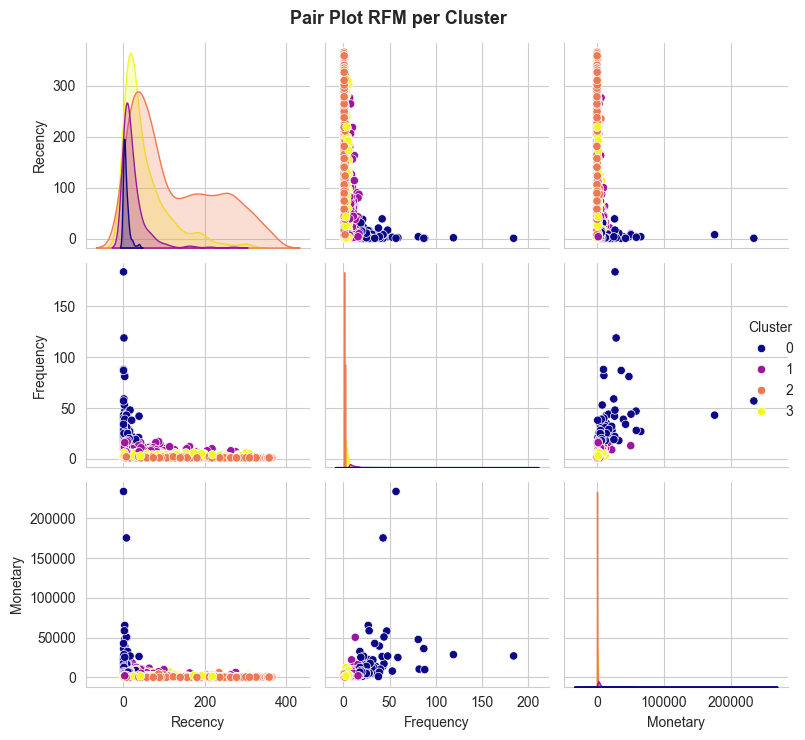

In [68]:
# Menampilkan Pair Plot masing-masing variabel pada RFM per Cluster
pairplot = sns.pairplot(data=df_hdb, vars=columns, hue='Cluster', palette='plasma')
fig = pairplot.figure
fig.suptitle('Pair Plot RFM per Cluster', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

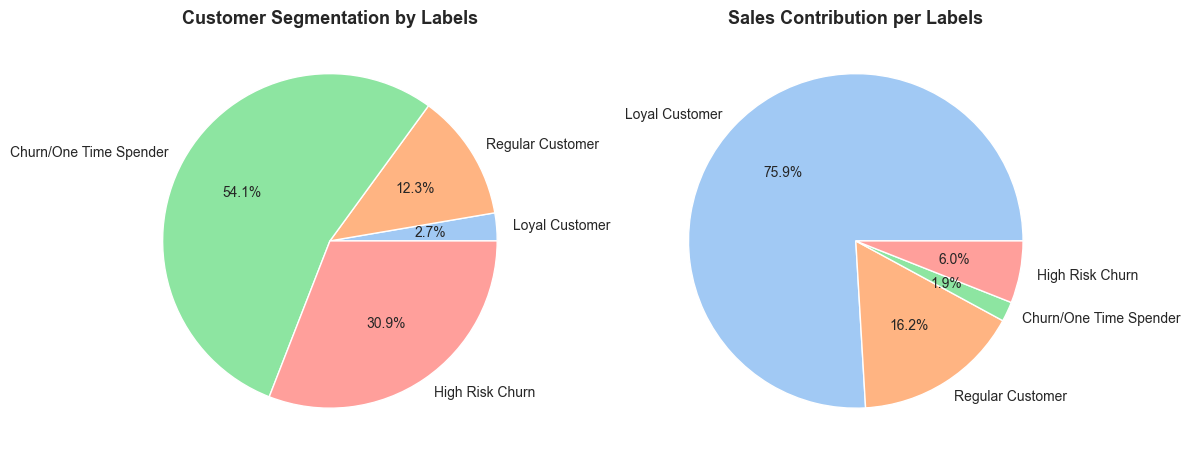

In [69]:
# Menampikan Pie Chart segmentasi Customer per Cluster
values = []
labels = []

values.append(cluster_analysis['Percentage'])
labels.append(cluster_analysis['Label'])
values.append(cluster_analysis['Avg_Monetary'])
labels.append(cluster_analysis['Label'])

fig, axes = plt.subplots(1, 2, figsize=(12, 12))
axes = axes.flatten()

axes[0].pie(x=values[0], labels=labels[0], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(labels[0])))
axes[0].set_title('Customer Segmentation by Labels', fontsize=13, weight='bold')
axes[1].pie(x=values[1], labels=labels[1], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(labels[1])))
axes[1].set_title('Sales Contribution per Labels', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

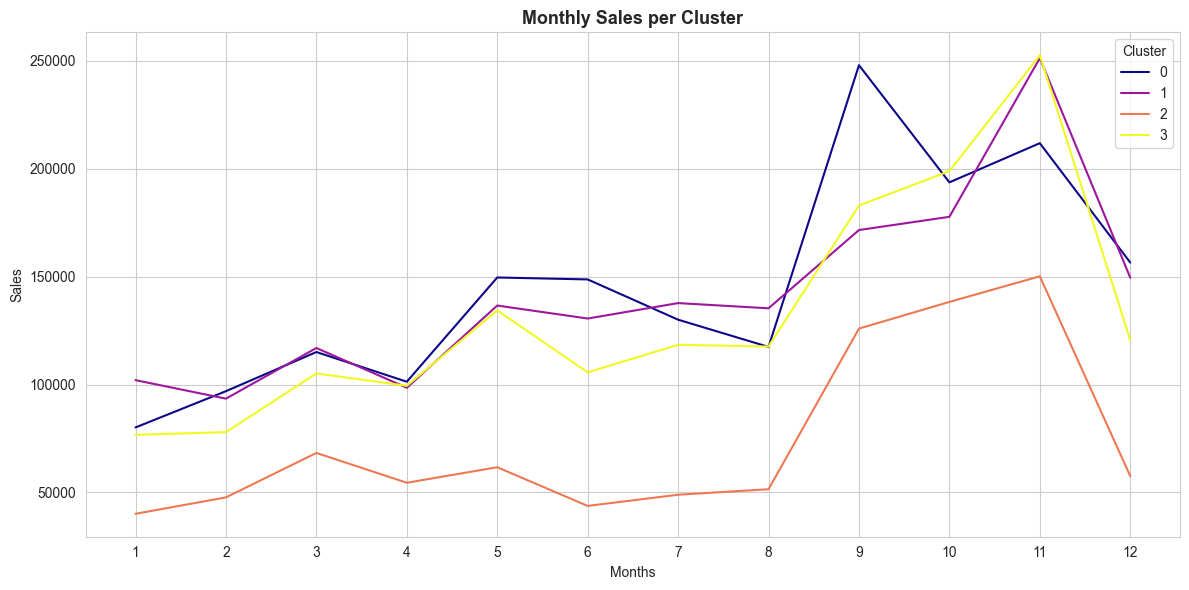

In [70]:
# Menampikan Line Chart total Sales masing-masing Cluster per Months
df_months = df_final.copy()
df_months['Months'] = df_months['InvoiceDate'].dt.month
monthly_sales_cluster = df_months.groupby(['Cluster', 'Months'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.lineplot(x='Months', y='Sales', data=monthly_sales_cluster, palette='plasma', hue='Cluster', ax=ax)
ax.set_title('Monthly Sales per Cluster', fontsize=13, weight='bold')
ax.set_xticks(range(1, 13))

fig.tight_layout()
plt.show()

Melakukan Analisa Category per Cluster

In [71]:
# Menampilkan rasio transaksi Customer per Category
sales_by_category = df_final.groupby(['CustomerID', 'Cluster', 'Category'])['Sales'].sum().unstack()

sales_by_category.head()

,Category,bags,baking,christmas,clocks,decoration,furniture,garden,kids,kitchen,lighting,others,stationery,storage
CustomerID,Cluster,,,,,,,,,,,,,
12747.0,1,384.80,NaN,NaN,NaN,1115.60,221.40,130.60,NaN,60.35,208.20,1716.50,NaN,NaN
12748.0,0,2140.83,458.62,1354.38,194.35,5927.16,409.81,1080.93,282.97,3611.14,2686.02,4125.31,2185.45,2568.87
12749.0,3,63.30,104.40,15.30,111.00,780.42,237.70,59.40,NaN,724.60,147.44,198.71,119.85,354.39
12820.0,3,118.80,NaN,165.72,NaN,258.52,NaN,NaN,9.36,32.00,84.60,37.80,114.60,120.94
12821.0,2,NaN,NaN,NaN,NaN,75.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00


In [72]:
# Mengambil Category dengan transaksi tertinggi sebagai representasi Customer
most_spend_category = sales_by_category.idxmax(axis=1).reset_index() 
most_spend_category.columns = ['CustomerID', 'Cluster', 'Category']

most_spend_category.sample(10)

,CustomerID,Cluster,Category
3325,17557.0,3,kitchen
2697,16665.0,2,kitchen
3563,17895.0,2,christmas
1730,15303.0,2,decoration
1036,14317.0,2,christmas
2461,16333.0,0,storage
3561,17893.0,2,decoration
1328,14730.0,1,decoration
340,13305.0,1,decoration
1047,14336.0,3,decoration


In [73]:
clusters = 4
cluster_category = []
cluster_category_analysis = []

for i in range(clusters):
    cluster_category.append(most_spend_category[most_spend_category['Cluster'] == i])
    cluster_category_analysis.append(cluster_category[i].groupby('Category').agg(
        Count = ('CustomerID', 'count'),
        Percentage = ('CustomerID', lambda x: (x.count() / len(cluster_category[i])) * 100)
        ).reset_index())

In [74]:
cluster_category_analysis

[     Category  Count  Percentage
 0        bags     24   23.300971
 1      baking      1    0.970874
 2   christmas      1    0.970874
 3      clocks      3    2.912621
 4  decoration     57   55.339806
 5     kitchen     10    9.708738
 6    lighting      2    1.941748
 7      others      2    1.941748
 8     storage      3    2.912621,
       Category  Count  Percentage
 0         bags     72   15.286624
 1       baking      3    0.636943
 2    christmas      1    0.212314
 3       clocks      3    0.636943
 4   decoration    261   55.414013
 5    furniture     11    2.335456
 6       garden      1    0.212314
 7         kids      2    0.424628
 8      kitchen     59   12.526539
 9     lighting      6    1.273885
 10      others     27    5.732484
 11  stationery      7    1.486200
 12     storage     18    3.821656,
       Category  Count  Percentage
 0         bags    143    6.891566
 1       baking     34    1.638554
 2    christmas     68    3.277108
 3       clocks      9    0.

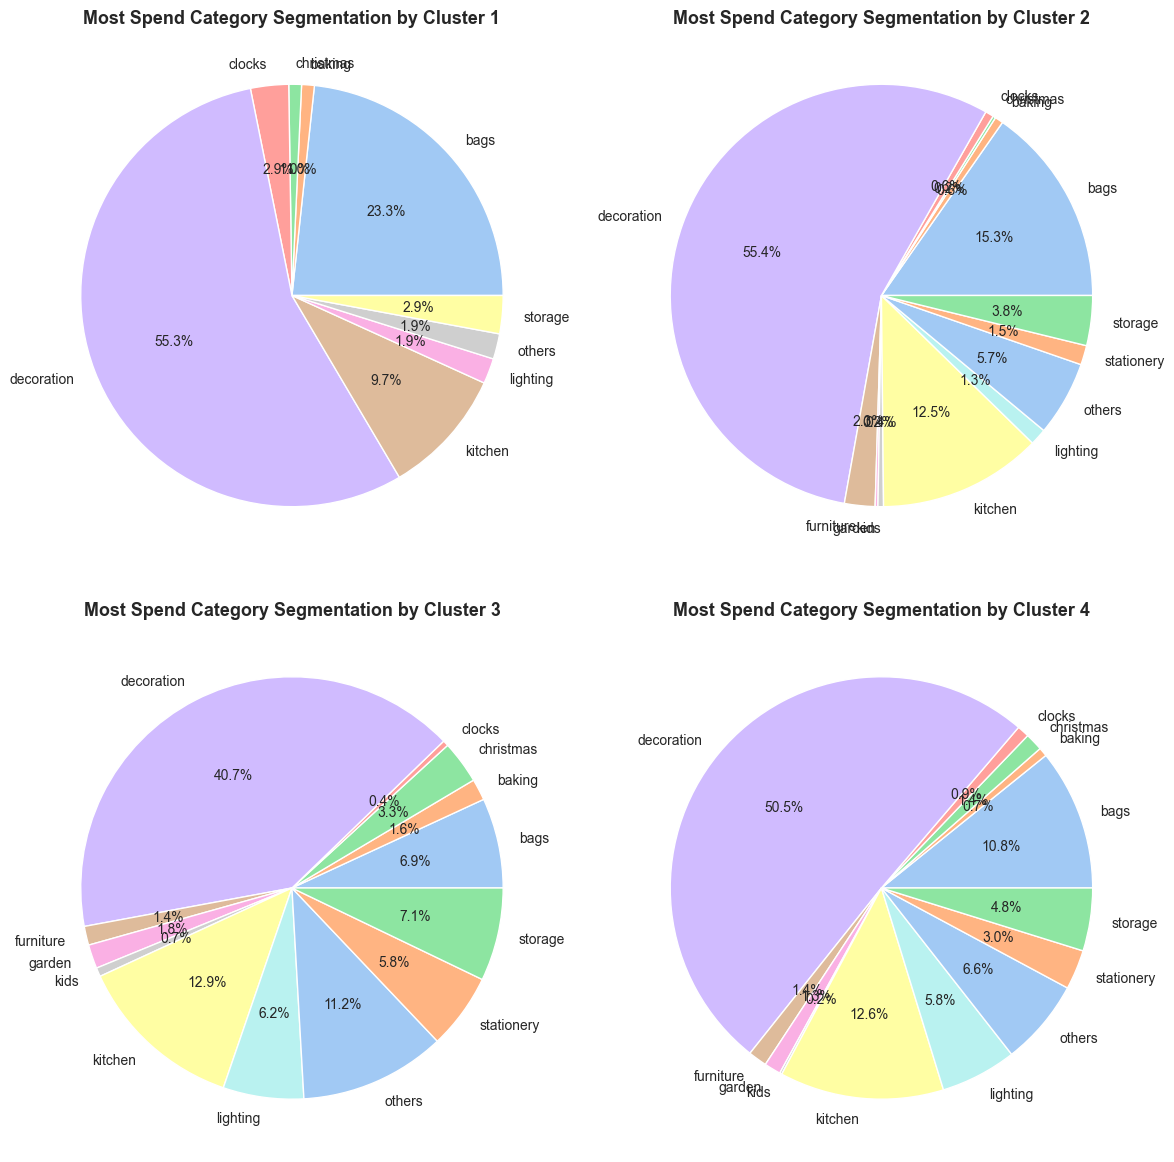

In [75]:
# Menampilkan Pie Chart rasio Category tertinggi per Cluster
values = []
labels = []

for i in range(clusters):
    values.append(cluster_category_analysis[i]['Percentage'])
    labels.append(cluster_category_analysis[i]['Category'])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.pie(x=values[i], labels=labels[i], autopct='%1.1f%%', colors = sns.color_palette('pastel', len(labels[i])))
    ax.set_title(f'Most Spend Category Segmentation by Cluster {i+1}', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

Melakukan Analisa Seasonality per Cluster

In [76]:
# Menampilkan rasio transaksi Customer per Seasonality
sales_by_seasonality = df_final.groupby(['CustomerID', 'Cluster', 'Seasonality'])['Sales'].sum().unstack()

sales_by_seasonality.head()

,Seasonality,Fall,Spring,Summer,Winter
CustomerID,Cluster,,,,
12747.0,1,988.11,1082.09,678.00,1089.25
12748.0,0,15804.79,3684.28,3627.06,3909.71
12749.0,3,554.69,592.60,1153.46,615.76
12820.0,3,561.53,NaN,NaN,380.81
12821.0,2,NaN,92.72,NaN,NaN


In [77]:
# Mengambil Seasonality dengan transaksi tertinggi sebagai representasi Customer
most_spend_seasonality = sales_by_seasonality.idxmax(axis=1).reset_index() 
most_spend_seasonality.columns = ['CustomerID', 'Cluster', 'Seasonality']

most_spend_seasonality.sample(10)

,CustomerID,Cluster,Seasonality
3812,18250.0,2,Winter
668,13780.0,2,Winter
554,13614.0,3,Fall
1326,14725.0,2,Fall
1458,14920.0,2,Spring
2243,16023.0,3,Spring
1934,15587.0,3,Fall
3549,17880.0,2,Winter
3216,17403.0,2,Fall
2175,15920.0,3,Summer


In [78]:
clusters = 4
cluster_seasonality = []
cluster_seasonality_analysis = []

for i in range(clusters):
    cluster_seasonality.append(most_spend_seasonality[most_spend_seasonality['Cluster'] == i])
    cluster_seasonality_analysis.append(cluster_seasonality[i].groupby('Seasonality').agg(
        Count = ('CustomerID', 'count'),
        Percentage = ('CustomerID', lambda x: (x.count() / len(cluster_seasonality[i])) * 100)
        ).reset_index())

In [79]:
cluster_seasonality_analysis

[  Seasonality  Count  Percentage
 0        Fall     58   56.310680
 1      Spring     19   18.446602
 2      Summer     11   10.679612
 3      Winter     15   14.563107,
   Seasonality  Count  Percentage
 0        Fall    235   49.893843
 1      Spring     71   15.074310
 2      Summer     84   17.834395
 3      Winter     81   17.197452,
   Seasonality  Count  Percentage
 0        Fall    934   45.012048
 1      Spring    444   21.397590
 2      Summer    362   17.445783
 3      Winter    335   16.144578,
   Seasonality  Count  Percentage
 0        Fall    551   46.497890
 1      Spring    228   19.240506
 2      Summer    227   19.156118
 3      Winter    179   15.105485]

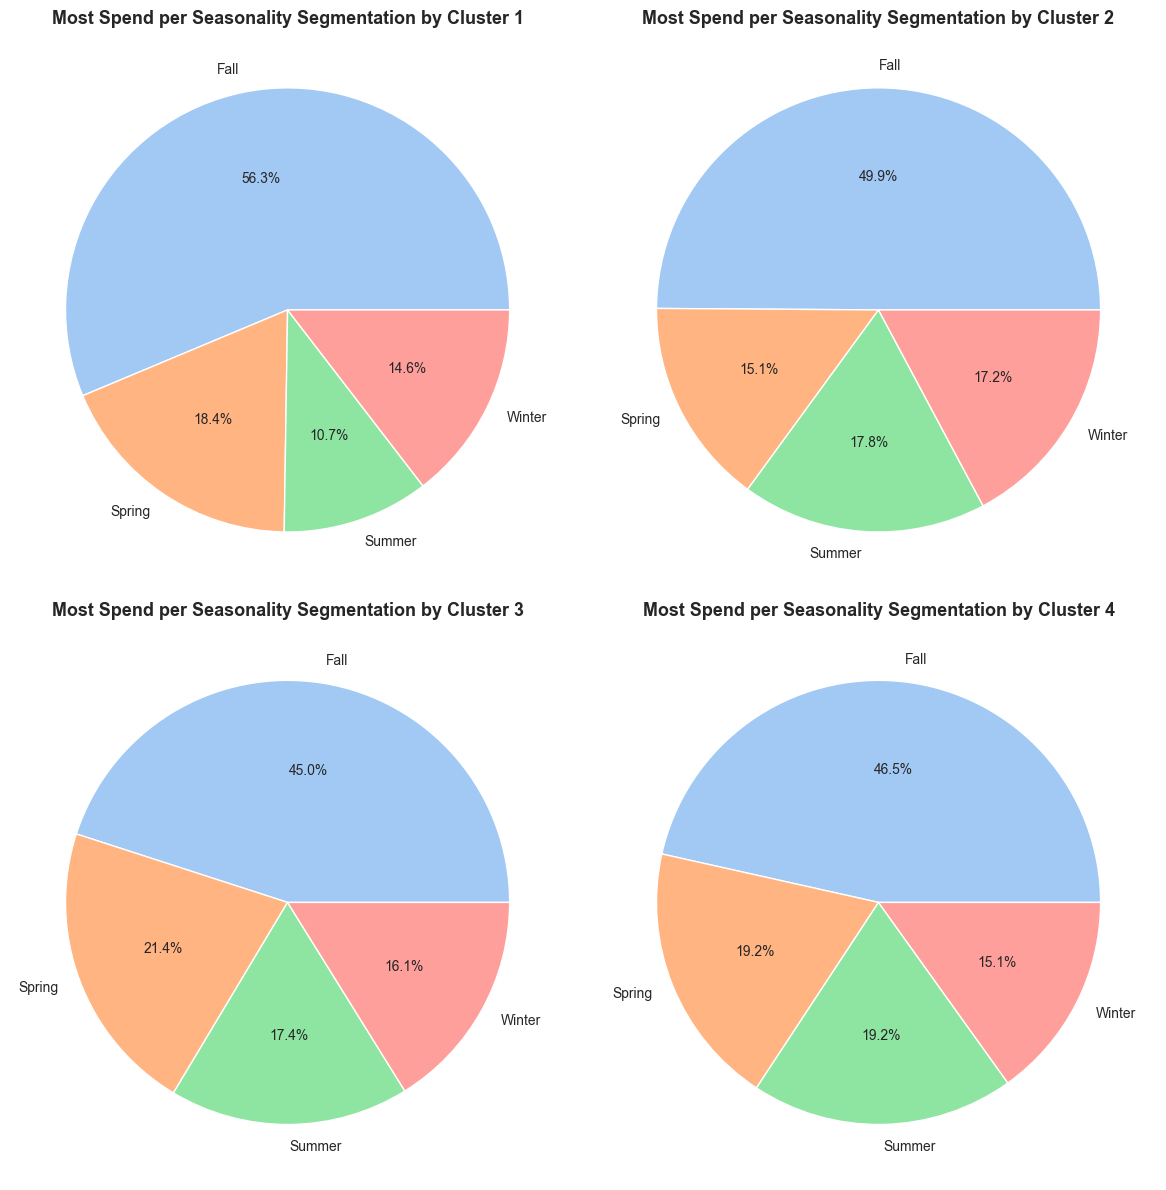

In [80]:
# Menampilkan Pie Chart rasio Seasonality tertinggi per Cluster
values = []
labels = []

for i in range(clusters):
    values.append(cluster_seasonality_analysis[i]['Percentage'])
    labels.append(cluster_seasonality_analysis[i]['Seasonality'])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.pie(x=values[i], labels=labels[i], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(labels[i])))
    ax.set_title(f'Most Spend per Seasonality Segmentation by Cluster {i+1}', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [81]:
df_hdb.groupby('Cluster')[columns].agg(['mean', 'min', 'max'])

Recency           Frequency               Monetary           \
               mean min  max       mean min  max          mean      min   
Cluster                                                                   
0          6.514563   1   39  31.533981  18  184  16986.133204  1168.89   
1         24.101911   1  276  10.010616   7   17   3612.710934   191.17   
2        125.522410   1  365   1.345060   1    2    428.185399     2.90   
3         54.336709   1  312   4.055696   3    6   1342.283833    36.56   

                    
               max  
Cluster             
0        233736.93  
1         50415.49  
2          6045.00  
3         12393.70

## Karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: Loyal Customer**
- **Rata-rata (mean) Recency:** 6.164948
- **Rata-rata (mean) Frequency:** 31.144330
- **Rata-rata (mean) Monetary:** 17212.509175
- **Kategori (Category):** Decoration, Bags
- **Musim (Seasonality):** Fall, Spring
- **Analisis:** Customer yang termasuk di cluster ini cenderung memiliki loyalitas tinggi dengan monetary yang tinggi. Pelanggan dalam cluster ini sering berbelanja.
- **Strategi marketing yang disarankan:** Prioritas VIP karena berdampak besar terhadap penjualan.
Contoh program yang dapat diterapkan adalah membership karena pelanggan akan datang untuk mendapatkan benefit dari membership.

2. **Cluster 2: Regular Customer**
- **Rata-rata (mean) Recency:** 21.943311
- **Rata-rata (mean) Frequency:** 9.959184
- **Rata-rata (mean) Monetary:** 3597.595737
- **Kategori (Category):** Decoration, Bags, Kitchen
- **Musim (Seasonality):** Fall, Summer
- **Analisis:** Customer pada cluster ini memiliki nilai RFM yang berada di tengah, mereka masih bertransaksi tetapi tidak berdampak besar terhadap penjualan.
- **Strategi marketing yang disarankan:** Berikan rekomendasi produk berkaitan dengan produk yang pernah dibeli customer.

3. **Cluster 3: Churn/One Time Spender**
- **Rata-rata (mean) Recency:** 119.924964
- **Rata-rata (mean) Frequency:** 1.345358
- **Rata-rata (mean) Monetary:** 430.092767
- **Kategori (Category):** Decoration, Kitchen, Others
- **Musim (Seasonality):** Fall, Spring
- **Analisis:** Customer dalam cluster ini pernah bertransaksi tetapi sekarang sudah tidak lagi.
- **Strategi marketing yang dapat digunakan:** Berikan promosi yang menarik agar mereka bertransaksi kembali contohnya dengan memberikan diskon yang besar bagi pelanggan yang dirasa memiliki nilai monetary bagus.
Jika dirasa tidak efisien, sebaiknya dianggap Churn karena tidak berdampak besar terhadap penjualan.

4. **Cluster 4: High Risk Churn**
- **Rata-rata (mean) Recency:** 51.587179
- **Rata-rata (mean) Frequency:** 4.070085
- **Rata-rata (mean) Monetary:** 1354.447574
- **Kategori (Category):** Decoration, Kitchen, Bags
- **Musim (Seasonality):** Fall, Spring, Summer
- **Analisis:** Customer dalam cluster ini masuk ke dalam kategori customer yang memiliki resiko untuk tidak lagi bertransaksi pada retail tersebut. customer pada cluster ini tergolong sudah lama tidak bertransaksi dengan frekuensi transaksi yang dibawah rata-rata. Dampak monetary yang diberikan juga tidak besar.
- **Strategi marketing yang disarankan:** Berikan quesioner alasan mereka sudah jarang bertransaksi (opsional) bisa juga digunakan untuk menarik kembali dengan cara memberikan pengalaman yang lebih baik setelah memperbaiki poin-poin customer.
Memberikan diskon agar customer lebih tertarik untuk bertransaksi.


End of Code.